In [1]:
import scipy.io as sio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FS          = 50_000                       # Hz
IDX_1000MS  = int(1.000 * FS)              # 1000 ms sample
STEP_GRID   = np.arange(-100, 325, 25)     # −100 … +300 pA

def _clean(k): return k.split("\x00")[0]

def load_currents_voltages(mat_path):
    m  = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    df = pd.DataFrame({_clean(k): np.asarray(v) for k, v in m.items()
                       if not k.startswith("__")})

    time_ms   = df.filter(regex="Time").iloc[:, 0].values * 1_000
    cur_cols  = sorted([c for c in df if "Current" in c],
                       key=lambda s: int(s.split('_')[0][1:]))
    volt_cols = sorted([c for c in df if "Voltage" in c],
                       key=lambda s: int(s.split('_')[0][1:]))

    currents  = [df[c].values * 1e12 for c in cur_cols]   #  ➜ pA
    voltages  = [df[c].values * 1e3  for c in volt_cols]  #  ➜ mV
    return time_ms, currents, voltages

def step_labels_by_point(currents, idx=IDX_1000MS):
    return [25 * round(I[idx] / 25) for I in currents]

def plot_iv_sweeps(mat_path,
                   low_pA=-np.inf, high_pA=np.inf,
                   *, what="V", legend=True, time_window=None, y_window=None):
    """
    Plot sweeps whose IV-step ∈ [low_pA, high_pA].
    what: 'V' | 'I' | 'both'  (two stacked axes for 'both')
    """
    assert what in {"V", "I", "both"}

    t_ms, I_list, V_list = load_currents_voltages(mat_path)
    step_pA = step_labels_by_point(I_list)
    keep    = [low_pA <= s <= high_pA for s in step_pA]

    if not any(keep):
        print(f"No sweeps between {low_pA} and {high_pA} pA")
        return

    # ---------- create axes ----------
    if what == "both":
        fig, (axI, axV) = plt.subplots(2, 1, sharex=False, figsize=(7, 6),
                                        gridspec_kw=dict(hspace=0.1))
    else:
        fig, ax = plt.subplots(figsize=(6, 5))

    # ---------- plot ----------
    for I, V, step, ok in zip(I_list, V_list, step_pA, keep):
        if not ok:
            continue
        lbl = f"{step:+.0f} pA" if legend else None

        if what in {"I", "both"}:
            target = axI if what == "both" else ax
            target.plot(t_ms, I, lw=0.8, alpha=0.85, label=lbl)

        if what in {"V", "both"}:
            target = axV if what == "both" else ax
            target.plot(t_ms, V, lw=0.8, alpha=0.85, label=lbl)

    # ---------- cosmetics ----------
    if time_window:
        (axI if what == "both" else ax).set_xlim(*time_window)

    if y_window:
        (axI if what == "both" else ax).set_ylim(*y_window)

    if what == "both":
        axI.set_ylabel("Injected I (pA)")
        axI.grid()
        axV.set_ylabel("Vm (mV)")
        axV.grid()
        axV.set_xlabel("Time (ms)")
        if legend:
            axI.legend(title="IV step", loc="upper right", ncol=2)
            axV.legend(title="IV step", loc="upper right", ncol=2)
        fig.suptitle(f"Traces with {low_pA} ≤ I ≤ {high_pA} pA")
    else:
        ax.set_xlabel("Time (ms)")
        ax.set_ylabel("Injected I (pA)" if what == "I" else "Vm (mV)")
        if legend:
            ax.legend(title="IV step", ncol=2)
        ax.set_title(f"Traces with {low_pA} ≤ I ≤ {high_pA} pA")
        ax.grid()

    plt.tight_layout()
    plt.show()


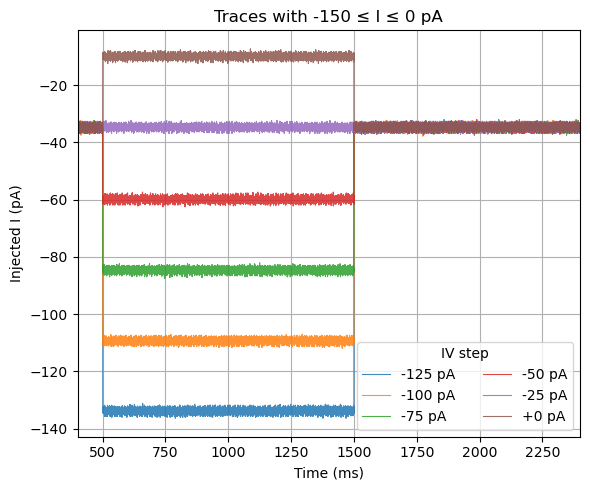

In [11]:
# # Voltage only, -100 pA to +450 pA

# plot_iv_sweeps("/home/hrbncv/PV-SST/single_cells/Madhu_Data/MAT_Analysis/data/PV_data.mat", 
#                275, 350, what="V",time_window=(400,1900),y_window=(-80,40))

# # Current traces only, hyperpolarizing band −100 pA to 0 pA
plot_iv_sweeps("/home/hrbncv/PV-SST/single_cells/Madhu_Data/MAT_Analysis/data/SST_data.mat", 
               -150,0, what="I",time_window=(400,2400),y_window=(None,None))

# # Plot both traces for firing inducing currents
# plot_iv_sweeps("/home/hrbncv/PV-SST/single_cells/Madhu_Data/MAT_Analysis/data/SST_data.mat", 
#                -150, 150, what="V",time_window=(450,1650),y_window=(-80,50))


Analysis

In [3]:
import numpy as np
from scipy.signal import savgol_filter, find_peaks

# Constants (unchanged)
FS            = 50_000        # Hz
SAVGOL_WIN    = 11            # smoothing window (samples), must be odd
SAVGOL_POLY   = 3             # polynomial order
DV_DT_THRESH  = 15.0          # mV/ms threshold for spike onset
MIN_V_PEAK    = -20.0         # mV – minimum peak to count
HALF_REF      = 0.5           # 50% of spike amplitude
REST_WIN_MS   = 5             # ms to average for resting V
STEP_AT_MS    = 1000          # ms to sample current for step label

def smooth(v):
    return savgol_filter(v, SAVGOL_WIN, SAVGOL_POLY)

def dv_dt(v):
    # v in mV; dt = 1/FS → derivative * FS gives mV/ms
    return np.diff(v) * FS

def detect_spikes(v):
    """
    Return indices of AP peaks.
    Criteria:
      1) dV/dt crosses DV_DT_THRESH,
      2) Local maximum ≥ MIN_V_PEAK,
      3) Enforce a minimum distance of 1 ms between peaks.
    """
    dv = dv_dt(smooth(v))
    thr_cross = np.where(dv > DV_DT_THRESH)[0]
    if thr_cross.size == 0:
        return np.array([], dtype=int)

    peaks, _ = find_peaks(v, height=MIN_V_PEAK, distance=int(0.001 * FS))
    # keep only peaks that follow at least one threshold crossing
    valid = [p for p in peaks if np.any(thr_cross < p)]
    return np.array(valid, dtype=int)

def ap_metrics(v, peaks):
    """
    Calculate AP metrics for each peak index in `peaks`.
    Returns a list of dicts, one per spike. If half‐width fails, set NaN.
    """
    metrics = []
    for pk in peaks:
        # 1) Find threshold: first dv/dt > threshold within 2 ms before pk
        lookback = int(0.002 * FS)
        dv = dv_dt(smooth(v))
        window_start = max(pk - lookback, 0)
        idx_candidates = np.where(dv[window_start:pk] > DV_DT_THRESH)[0]
        if idx_candidates.size:
            thr_idx = window_start + idx_candidates[0]
            Vthr = v[thr_idx]
        else:
            # no clear threshold crossing → skip this spike
            continue

        # 2) Peak voltage & amplitude
        Vpk = v[pk]
        amp = Vpk - Vthr

        # 3) Half‐width: find left and right crossings at half‐height
        half_level = Vthr + HALF_REF * amp
        # Left side (between thr_idx and pk)
        left_candidates = np.where(v[thr_idx:pk] >= half_level)[0]
        if left_candidates.size:
            left = thr_idx + left_candidates[0]
        else:
            left = None

        # Right side (after pk)
        right_candidates = np.where(v[pk:] <= half_level)[0]
        if right_candidates.size:
            right = pk + right_candidates[0]
        else:
            right = None

        if left is not None and right is not None and right > left:
            half_width_ms = (right - left) / FS * 1_000
        else:
            half_width_ms = np.nan

        # 4) After‐hyperpolarisation in the 0–5 ms window after pk
        ahp_window = v[pk : pk + int(0.005 * FS)]
        if ahp_window.size:
            Vmin = np.min(ahp_window)
            AHP_depth = Vthr - Vmin
            AHP_latency_ms = np.argmin(ahp_window) / FS * 1_000
        else:
            Vmin = np.nan
            AHP_depth = np.nan
            AHP_latency_ms = np.nan

        metrics.append(dict(
            V_thr_mV      = Vthr,
            V_peak_mV     = Vpk,
            amp_mV        = amp,
            half_width_ms = half_width_ms,
            AHP_min_mV    = Vmin,
            AHP_depth_mV  = AHP_depth,
            AHP_lat_ms    = AHP_latency_ms
        ))

    return metrics


In [4]:
import numpy as np
import pandas as pd

def analyse_cell(time_ms, I_traces, V_traces, stim_period_ms=(500, 1500)):
    """
    Return sweep-level and spike-level DataFrames.

    stim_period_ms : tuple (start, end) in ms.
                     Only spikes whose peak time lies inside this window
                     are counted for firing-rate / FI curve metrics.
    """
    # 1) Label each sweep by its injected step (one sample at 1000 ms)
    idx_step = int(STEP_AT_MS / 1000 * FS)
    step_pA_list = [25 * round(I[idx_step] / 25) for I in I_traces]

    # 2) Precompute indices for stimulus window
    t_arr = np.asarray(time_ms)
    stim_start_idx = np.searchsorted(t_arr, stim_period_ms[0])
    stim_end_idx   = np.searchsorted(t_arr, stim_period_ms[1])

    sweep_records = []
    spike_records = []

    # 3) Loop over sweeps
    for sw, (I, V, step_pA) in enumerate(zip(I_traces, V_traces, step_pA_list)):
        # Detect peaks across the entire sweep, then keep only those inside stim window
        all_peaks = detect_spikes(V)
        peaks_in_window = [p for p in all_peaks if stim_start_idx <= p < stim_end_idx]

        # 4) Count spikes & compute firing rate (Hz) only during stimulus window
        n_spikes = len(peaks_in_window)
        stim_duration_s = (stim_period_ms[1] - stim_period_ms[0]) / 1_000
        freq_hz = n_spikes / stim_duration_s if stim_duration_s > 0 else 0.0

        sweep_records.append(dict(
            sweep    = sw,
            step_pA  = step_pA,
            n_spikes = n_spikes,
            freq_hz  = freq_hz
        ))

        # 5) Per‐spike metrics (threshold, peak, etc.) using only peaks_in_window
        for spike_peak_idx in peaks_in_window:
            for m in ap_metrics(V, [spike_peak_idx]):
                spike_records.append(dict(
                    sweep    = sw,
                    step_pA  = step_pA,
                    **m
                ))

    sweep_df = pd.DataFrame(sweep_records)
    spike_df = pd.DataFrame(spike_records)
    return sweep_df, spike_df

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_AP_metrics(
        sweep_df, spike_df,
        *,
        # FI curve (on/off)
        freq_hz=True,
        # AP metrics
        V_thr_mV=True, V_peak_mV=True, amp_mV=True,
        half_width_ms=True, AHP_min_mV=True,
        AHP_depth_mV=True, AHP_lat_ms=True,
        # Common styling
        xlim=None,                    # tuple (xmin, xmax) in pA
        point_size=50,
        color="tab:blue",
        connect=False,
        fit=False,                    # draw least-squares fit
        figsize=(6, 6),
        marker="o",
        grid=True
    ):
    """
    Make one subplot per selected metric vs injected current (step_pA),
    plus FI‐curve slope & rheobase printing.

    - Zero‐frequency points are plotted, but NOT used in the fit.
    - The full fit equation is shown in the legend; only the slope prints.

    Parameters
    ----------
    sweep_df : DataFrame with columns ["step_pA", "freq_hz", ...]
    spike_df : DataFrame with columns ["step_pA", "V_thr_mV", "V_peak_mV", ...]
    freq_hz  : bool, include the FI curve (n_spikes / stim_duration)
    V_thr_mV, V_peak_mV, amp_mV, half_width_ms, AHP_min_mV,
    AHP_depth_mV, AHP_lat_ms : bool, toggle each AP metric on/off
    xlim     : (xmin, xmax) in pA for the x‐axis
    point_size : scatter‐plot marker size
    color    : color for all scatters & fits
    connect  : bool, draw a line connecting the points
    fit      : bool, perform & draw a least‐squares fit; prints slope for FI
    figsize  : height & width per subplot (height = “n_axes × figsize[1]”)
    marker   : matplotlib marker style (e.g. "o", "s", ...)
    grid     : bool, draw grid‐lines in each axis
    """

    # --- 1. Gather all requested metrics into a dict of flags ------------
    metric_flags = dict(
        freq_hz=freq_hz,
        V_thr_mV=V_thr_mV, V_peak_mV=V_peak_mV, amp_mV=amp_mV,
        half_width_ms=half_width_ms, AHP_min_mV=AHP_min_mV,
        AHP_depth_mV=AHP_depth_mV, AHP_lat_ms=AHP_lat_ms
    )

    selected = [m for m, on in metric_flags.items() if on]
    if not selected:
        raise ValueError("No metrics selected!  Turn on at least one flag.")

    # --- 2. Compute rheobase and print it if FI is in “selected” --------------
    if "freq_hz" in selected:
        nonzero = sweep_df.loc[sweep_df["freq_hz"] > 0, "step_pA"]
        if len(nonzero) > 0:
            rheobase = nonzero.min()
            print(f"→ Rheobase = {rheobase} pA")
        else:
            print("→ Rheobase: no spikes detected at any step.")

    # --- 3. Build per‐sweep averages for spike metrics ----------------------
    spike_mean = spike_df.groupby("step_pA").mean(numeric_only=True)
    sweep_metrics = sweep_df.set_index("step_pA")

    # --- 4. Create subplots, one per metric --------------------------------
    n_axes = len(selected)
    fig, axes = plt.subplots(
        n_axes, 1,
        sharex=True,
        figsize=(figsize[0], figsize[1] * n_axes),
        gridspec_kw=dict(hspace=0.2)
    )
    if n_axes == 1:
        axes = [axes]  # make iterable

    # --- 5. Loop through each metric and plot -------------------------------
    for ax, metric in zip(axes, selected):
        if metric == "freq_hz":
            # FI: plot all points, but fit only nonzero
            y_all = sweep_metrics["freq_hz"].dropna()
            x_all = y_all.index.values

            # Plot zero AND nonzero points
            ax.scatter(x_all, y_all.values,
                       s=point_size, color=color, marker=marker, zorder=3)

            # Optionally connect ALL points
            if connect and x_all.size > 1:
                ax.plot(x_all, y_all.values, color=color, linewidth=1)

            # Fit ONLY on freq > 0
            if fit:
                mask_fit = y_all.values > 0
                x_fit = x_all[mask_fit]
                y_fit = y_all.values[mask_fit]
                if x_fit.size > 1:
                    m, b = np.polyfit(x_fit, y_fit, 1)
                    # Draw the fit line across the full plotted x-range
                    x_line = np.array([x_fit.min(), x_fit.max()])
                    y_line = m * x_line + b
                    ax.plot(x_line, y_line,
                            color=color, linestyle="--", linewidth=1,
                            label=f"y = {m:.3f}·x + {b:.3f}")
                    print(f"→ FI slope = {m:.3f} Hz/pA")
                    ax.legend(loc="best", fontsize="x-small")
        else:
            # AP metric: use all available sweeps that have a mean in spike_mean
            if metric in spike_mean.columns:
                y_all = spike_mean[metric].dropna()
                x_all = y_all.index.values

                ax.scatter(x_all, y_all.values,
                           s=point_size, color=color, marker=marker, zorder=3)

                if connect and x_all.size > 1:
                    ax.plot(x_all, y_all.values, color=color, linewidth=1)

                if fit and x_all.size > 1:
                    m, b = np.polyfit(x_all, y_all.values, 1)
                    x_line = np.array([x_all.min(), x_all.max()])
                    y_line = m * x_line + b
                    ax.plot(x_line, y_line,
                            color=color, linestyle="--", linewidth=1,
                            label=f"y = {m:.3f}·x + {b:.3f}")
                    ax.legend(loc="best", fontsize="x-small")
            else:
                # No data for that metric
                ax.text(0.5, 0.5, "no data", ha="center", va="center", color="gray")
                ax.set_ylim(0, 1)

        # Label each subplot
        ax.set_ylabel(metric.replace("_", "\n"), fontsize=9)
        if grid:
            ax.grid(True, linewidth=0.3, alpha=0.6)

    # --- 6. Final touches on X‐axis -----------------------------------------
    axes[-1].set_xlabel("Injected current (pA)")
    if xlim:
        axes[-1].set_xlim(*xlim)

    # plt.tight_layout()
    plt.show()


In [6]:
# # Voltage only, -100 pA to +450 pA
# plot_iv_sweeps("PV_example.mat", 350, 350, what="V",time_window=(450,1550),y_window=(-80,20))

# # Current traces only, hyperpolarizing band −100 pA to 0 pA
# # plot_iv_sweeps("SST_example.mat", -100, 225, what="both")

# # Plot both traces for firing inducing currents
# plot_iv_sweeps("PyrExample.mat", 400, 400, what="V",time_window=(450,1550),y_window=(-80,60))


In [7]:
# 1) Load your .mat file as before:
cell_data = "SST_data"
time_ms, I_traces, V_traces = load_currents_voltages(f'data/{cell_data}.mat')

# 2) Analyse with the fixed functions:
sweep_df, spike_df = analyse_cell(
    time_ms, I_traces, V_traces, stim_period_ms=(500, 1500)
)


# 3) Plot the FI curve and AP metrics:
plot_AP_metrics(
    sweep_df, spike_df,
    freq_hz=True,
    V_thr_mV=False, V_peak_mV=False, amp_mV=False,
    half_width_ms=False, AHP_min_mV=False,
    AHP_depth_mV=False, AHP_lat_ms=False,
    xlim=(-100, 450),
    connect=True, fit=True,
    point_size=40, color="Blue"
)

# plot_AP_metrics(
#     sweep_df, spike_df,
#     freq_hz=True, V_peak_mV=True, half_width_ms=True,
#     V_thr_mV=True, amp_mV=True,
#     AHP_min_mV=True, AHP_depth_mV=True, AHP_lat_ms=True,
#     xlim=(300, 450),
#     connect=True, fit=True,
#     point_size=40, color="crimson"
# )

FileNotFoundError: [Errno 2] No such file or directory: 'data/SST_data.mat'

In [ ]:
# ============================================================
#  Electrophysiology “IV-family” Analysis Pipeline
#  ------------------------------------------------------------
#  • Loads .mat files that contain paired I & V sweeps
#  • Detects spikes, extracts sweep- and spike-level metrics
#  • Plots one or many metrics across any number of datasets
#  ------------------------------------------------------------
#  Paste this entire cell into a Jupyter notebook and run once.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
import scipy.io as sio

# ------------------------------------------------------------------
# 0️⃣  GLOBAL CONFIGURATION  (edit these to suit your rig)
# ------------------------------------------------------------------
FS               = 50_000      # <— sampling rate [Hz]
SAVGOL_WIN       = 11          # Savitzky–Golay window (odd samples)
SAVGOL_POLY      = 3           # SG polynomial order
DV_DT_THRESH     = 15.0        # dV/dt threshold [mV/ms] for spike onset
MIN_V_PEAK       = 0.0         # minimum peak amplitude [mV] (ignore bumps < 0 mV)
MIN_PEAK_DIST_MS = 5           # refractory: min distance between spikes [ms]
HALF_REF         = 0.5         # half-width reference (0.5 = 50 % amplitude)
STEP_AT_MS       = 1000        # time-point used to label injected current [ms]

# A colour per dataset key (extend as needed)
COLORS = {"PN": "red",
          "PV": "blue",
          "SST": "magenta",
          "__default__": "black"}

POINT_SIZE = 25    # scatter size for plots
CONNECT     = True # connect successive points with a line

# ------------------------------------------------------------------
# 1️⃣  LOW-LEVEL SIGNAL HELPERS
# ------------------------------------------------------------------
def smooth(v: np.ndarray) -> np.ndarray:
    """Savitzky–Golay smoothing (mild, preserves spike amplitudes)."""
    return savgol_filter(v, SAVGOL_WIN, SAVGOL_POLY)

def dv_dt(v: np.ndarray) -> np.ndarray:
    """dV/dt in mV/ms (first difference × fs)."""
    return np.diff(v) * FS

# ------------------------------------------------------------------
# 2️⃣  SPIKE DETECTION
# ------------------------------------------------------------------
def detect_spikes(v: np.ndarray) -> np.ndarray:
    """
    Return indices of spike peaks.

    1. Smooth the trace slightly.
    2. Find all points where dV/dt > DV_DT_THRESH.
    3. Apply `scipy.signal.find_peaks` with:
          • min peak height = MIN_V_PEAK
          • min peak distance = MIN_PEAK_DIST_MS
    4. Keep only peaks that follow at least one threshold crossing.
    """
    dv = dv_dt(smooth(v))
    thr_cross = np.where(dv > DV_DT_THRESH)[0]
    if thr_cross.size == 0:
        return np.array([], dtype=int)

    min_dist = int(MIN_PEAK_DIST_MS / 1000 * FS)
    peaks, _ = find_peaks(v,
                          height=MIN_V_PEAK,
                          distance=min_dist)
    valid = [p for p in peaks if np.any(thr_cross < p)]
    return np.array(valid, dtype=int)

# ------------------------------------------------------------------
# 3️⃣  PER-SPIKE AP METRICS
# ------------------------------------------------------------------
def ap_metrics(v: np.ndarray, peaks: list[int]) -> list[dict]:
    """
    Calculate classic AP shape metrics for every peak index in `peaks`.

    Missing measurements (e.g. half-width when crossings cannot be found)
    are returned as NaN to avoid crashing downstream code.
    """
    out = []
    for pk in peaks:
        # —— threshold (first dV/dt > threshold within 2 ms pre-peak)
        lookback = int(0.002 * FS)
        dv = dv_dt(smooth(v))
        win0 = max(pk - lookback, 0)
        idx = np.where(dv[win0:pk] > DV_DT_THRESH)[0]
        if idx.size == 0:
            # cannot define threshold → skip this spike
            continue
        thr_idx = win0 + idx[0]
        Vthr = v[thr_idx]

        Vpk  = v[pk]
        amp  = Vpk - Vthr

        # —— half-width
        half_level = Vthr + HALF_REF * amp
        left  = np.where(v[thr_idx:pk] >= half_level)[0]
        right = np.where(v[pk:]       <= half_level)[0]
        if left.size and right.size:
            hw_ms = ( (thr_idx + left[0]) - (pk + right[0]) ) / FS * -1000
        else:
            hw_ms = np.nan

        # —— AHP (0–5 ms post-peak)
        ahp_seg = v[pk : pk + int(0.005*FS)]
        if ahp_seg.size:
            Vmin = ahp_seg.min()
            AHP_depth = Vthr - Vmin
            AHP_lat   = ahp_seg.argmin() / FS * 1000
        else:
            Vmin = AHP_depth = AHP_lat = np.nan

        out.append(dict(
            V_thr_mV      = Vthr,
            V_peak_mV     = Vpk,
            amp_mV        = amp,
            half_width_ms = hw_ms,
            AHP_min_mV    = Vmin,
            AHP_depth_mV  = AHP_depth,
            AHP_lat_ms    = AHP_lat
        ))
    return out

# ------------------------------------------------------------------
# 4️⃣  .mat LOADER (LabChart-style flat struct)
# ------------------------------------------------------------------
def load_currents_voltages(mat_path: str):
    """
    Parameters
    ----------
    mat_path : path to .mat containing columns:
        c001_Time, c002_Current_2, c003_Voltage_2, ...

    Returns
    -------
    time_ms   : 1-D np.ndarray [ms]
    I_traces  : list[np.ndarray]   (pA)
    V_traces  : list[np.ndarray]   (mV)
    """
    def clean(k): return k.split("\x00")[0]

    m  = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)
    df = pd.DataFrame({clean(k): np.asarray(v)
                       for k, v in m.items()
                       if not k.startswith("__")})

    time_ms   = df.filter(regex="Time").iloc[:, 0].values * 1000
    cur_cols  = sorted([c for c in df if "Current" in c],
                       key=lambda s: int(s.split('_')[0][1:]))
    volt_cols = sorted([c for c in df if "Voltage" in c],
                       key=lambda s: int(s.split('_')[0][1:]))

    I_traces  = [df[c].values * 1e12 for c in cur_cols]   # A → pA
    V_traces  = [df[c].values * 1e3  for c in volt_cols]  # V → mV
    return time_ms, I_traces, V_traces

# ------------------------------------------------------------------
# 5️⃣  ANALYSE ONE CELL
# ------------------------------------------------------------------
def analyse_cell(time_ms,
                 I_traces,
                 V_traces,
                 stim_period_ms=(500, 1500),
                 auto_detect=False,
                 auto_thresh=0.7):
    """
    Detect spikes, compute sweep-level (FI) & spike-level metrics.

    Parameters
    ----------
    stim_period_ms : (start, end) tuple; spikes are counted only inside.
    auto_detect    : if True, detect the plateau window from sweep 0 (safer).
    auto_thresh    : fraction of max|I| to select plateau when auto_detect.

    Returns
    -------
    sweep_df : DataFrame  (one row per sweep)
        ├─ step_pA, n_spikes, freq_hz
    spike_df : DataFrame  (one row per spike)
        ├─ step_pA + AP metrics (threshold, peak, half-width, ...)
    """

    # —— 1. define stimulation window
    if auto_detect:
        I0 = I_traces[0]
        idx = np.where(np.abs(I0) >= auto_thresh * np.max(np.abs(I0)))[0]
        if idx.size == 0:
            raise RuntimeError("auto_detect failed: no plateau found.")
        stim_start_ms = idx.min() / FS * 1000
        stim_end_ms   = idx.max() / FS * 1000
        print(f"• Auto-detected stim window: {stim_start_ms:.0f}–{stim_end_ms:.0f} ms")
    else:
        stim_start_ms, stim_end_ms = stim_period_ms

    stim_start_idx = np.searchsorted(time_ms, stim_start_ms)
    stim_end_idx   = np.searchsorted(time_ms, stim_end_ms)
    stim_dur_s     = (stim_end_ms - stim_start_ms) / 1000

    # —— 2. label sweeps by injected current (value at STEP_AT_MS)
    idx_step = int(STEP_AT_MS / 1000 * FS)
    step_pA = [25 * round(I[idx_step] / 25) for I in I_traces]

    sweep_rec, spike_rec = [], []

    # —— 3. sweep-by-sweep loop
    for sw, (I, V, step) in enumerate(zip(I_traces, V_traces, step_pA)):
        peaks = detect_spikes(V)
        peaks = [p for p in peaks if stim_start_idx <= p < stim_end_idx]

        n_spk  = len(peaks)
        freq_hz = n_spk / stim_dur_s if stim_dur_s else 0

        sweep_rec.append(dict(
            sweep=sw, step_pA=step,
            n_spikes=n_spk, freq_hz=freq_hz
        ))

        for m in ap_metrics(V, peaks):
            spike_rec.append(dict(sweep=sw, step_pA=step, **m))

    return (pd.DataFrame(sweep_rec),
            pd.DataFrame(spike_rec))

# ------------------------------------------------------------------
# 6️⃣  LOAD ONE DATASET CONVENIENTLY
# ------------------------------------------------------------------
def load_dataset(tag: str,
                 mat_path: str,
                 stim=(500, 1500),
                 auto=False) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Wrapper that produces (sweep_df, spike_df) for one .mat file.

    tag      : label (e.g. "PN")
    mat_path : "PN_data.mat"
    stim     : (start, end) ms OR ignored if auto=True
    auto     : auto-detect plateau window from first sweep’s current
    """
    time_ms, I_tr, V_tr = load_currents_voltages(mat_path)
    return analyse_cell(time_ms, I_tr, V_tr,
                        stim_period_ms=stim,
                        auto_detect=auto)

# ------------------------------------------------------------------
# 7️⃣  MULTI-DATASET PLOTTING
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# ————————————————————————————————————————————————————————————————
#  plot_AP_metrics_multi:
#
#  • Multi‐panel plot: one row per metric, shared x‐axis = injected current (pA).
#  • Combined legend entries on every panel:
#      – FI curve: "{dot} KEY (R: ### pA, S: #.###)"
#      – Other metrics: "{dot} KEY"
#  • Descriptive Y‐axis labels and automatic titles.
# ————————————————————————————————————————————————————————————————

def plot_AP_metrics_multi(
        datasets: dict,
        *,
        freq_hz=None,
        V_thr_mV=None, V_peak_mV=None, amp_mV=None,
        half_width_ms=None, AHP_min_mV=None,
        AHP_depth_mV=None, AHP_lat_ms=None,
        xlim=None,
        fit=False,
        figsize=(6, 6),
        grid=True):
    """
    Plot selected AP metrics for multiple datasets in one figure.

    Parameters
    ----------
    datasets : dict
        Keys are identifiers (e.g., "PN", "PV", "SST"), values are
        (sweep_df, spike_df) tuples from analyse_cell().

    freq_hz, V_thr_mV, … : list[str] or None
        For each metric, supply a list of dataset keys to include in that panel.
        e.g. freq_hz=["PN","PV","SST"], V_peak_mV=["PN"], …
        None or [] means skip that metric.

    xlim : (xmin, xmax) in pA for the shared X‐axis (optional).

    fit : bool
        If True, perform a least‐squares fit.  In the FI panel, the fit uses only freq > 0.

    figsize : (width, height_per_panel)
        Each metric gets one vertical “height_per_panel” unit; total height = n_metrics × height_per_panel.

    grid : bool
        If True, draw light grid lines on every subplot.

    Behavior
    --------
    • Prints for each dataset in freq_hz:
        KEY → rheobase = ### pA, slope = #.### Hz/pA

    • On every subplot:
        – FI curve: plot points & fit, legend entry "{dot} KEY (R: ### pA, S: #.###)".
        – Other metrics: plot points & fit, legend entry "{dot} KEY".

    • Y‐axis labels are human‐readable:
        freq_hz → "Spikes (Hz)"
        V_thr_mV → "V_thr (mV)"
        V_peak_mV → "V_peak (mV)"
        amp_mV → "AP_amp (mV)"
        half_width_ms → "Half_width (ms)"
        AHP_min_mV → "AHP_min (mV)"
        AHP_depth_mV → "AHP_depth (mV)"
        AHP_lat_ms → "AHP_latency (ms)"

    Example
    -------
    plot_AP_metrics_multi(
        datasets,
        freq_hz       = ["PN", "PV", "SST"],
        V_peak_mV     = ["PN"],
        half_width_ms = ["SST"],
        xlim=(-100, 300),
        fit=True
    )
    """

    # ——————————————————————————————————————————————————————
    # 1. Build a map of metrics → requested dataset keys
    metric_map = {
        "freq_hz":       freq_hz or [],
        "V_thr_mV":      V_thr_mV or [],
        "V_peak_mV":     V_peak_mV or [],
        "amp_mV":        amp_mV or [],
        "half_width_ms": half_width_ms or [],
        "AHP_min_mV":    AHP_min_mV or [],
        "AHP_depth_mV":  AHP_depth_mV or [],
        "AHP_lat_ms":    AHP_lat_ms or []
    }
    # Filter out metrics with no datasets
    selected = {m: keys for m, keys in metric_map.items() if keys}

    if not selected:
        raise ValueError("No metrics selected—provide at least one nonempty list.")

    # ——————————————————————————————————————————————————————
    # 2. Prepare Y‐axis labels & subplot titles
    nice_labels = {
        "freq_hz":       "Spikes (Hz)",
        "V_thr_mV":      "V_thr (mV)",
        "V_peak_mV":     "V_peak (mV)",
        "amp_mV":        "AP_amp (mV)",
        "half_width_ms": "Half Width (ms)",
        "AHP_min_mV":    "AHP_min (mV)",
        "AHP_depth_mV":  "AHP_depth (mV)",
        "AHP_lat_ms":    "AHP_latency (ms)"
    }
    # Titles will be "<Label> vs. Injected Current"
    def make_title(metric):
        return f"{nice_labels[metric]} vs. Injected Current"

    # ——————————————————————————————————————————————————————
    # 3. Set up figure: one row per metric, shared X‐axis
    n_axes = len(selected)
    fig, axes = plt.subplots(
        n_axes, 1,
        sharex=True,
        figsize=(figsize[0], figsize[1]*n_axes),
        gridspec_kw=dict(hspace=0.25)
    )
    axes = np.atleast_1d(axes)

    # ——————————————————————————————————————————————————————
    # 4. Precompute FI stats (rheobase & slope) for each dataset, if requested
    fi_stats = {}  # key → {"rheobase": ..., "slope": ...}
    if "freq_hz" in selected and fit:
        for key in selected["freq_hz"]:
            if key not in datasets:
                continue
            sweep_df, _ = datasets[key]
            # 4a. Extract x_all, y_all for freq_hz
            y_all = sweep_df.set_index("step_pA")["freq_hz"].dropna()
            # 4b. Rheobase = first step_pA where freq_hz > 0
            nz = y_all[y_all > 0]
            rheo = float(nz.index.min()) if len(nz) else np.nan
            # 4c. Fit only points with freq > 0
            x_fit = nz.index.values
            y_fit = nz.values
            m = b = np.nan
            if len(x_fit) > 1:
                m, b = np.polyfit(x_fit, y_fit, 1)
            fi_stats[key] = {"rheobase": rheo, "slope": m, "intercept": b}

            # m = b = np.nan
            # if len(x_fit) > 1:
            #     m, b = np.polyfit(x_fit, y_fit, 1)
            # fi_stats[key] = {"rheobase": rheo,
            #                  "slope":    m,
            #                  "intercept": b}   # ← NEW

    # ——————————————————————————————————————————————————————
    # 5. Loop over metrics & plot each panel
    for ax, (metric, ds_keys) in zip(axes, selected.items()):
        for key in ds_keys:
            if key not in datasets:
                print(f"⚠  dataset '{key}' not found, skipping.")
                continue

            sweep_df, spike_df = datasets[key]
            color = COLORS.get(key, COLORS["__default__"])

            # 5a. Choose data source & get (x, y) pairs
            if metric == "freq_hz":
                y_all = sweep_df.set_index("step_pA")["freq_hz"].dropna()
            else:
                y_all = (
                    spike_df
                    .groupby("step_pA")
                    .mean(numeric_only=True)
                    .get(metric, pd.Series(dtype=float))
                    .dropna()
                )
            x_all = y_all.index.values

            # 5b. Scatter & connect
            ax.scatter(x_all, y_all.values,
                       s=POINT_SIZE, c=color, zorder=3)
            if CONNECT and x_all.size > 1:
                ax.plot(x_all, y_all.values, c=color, linewidth=1)

        # 5c. If fitting is requested, plot fit
        if fit and metric == "freq_hz":
            # After all datasets plotted, draw each dataset’s FI fit line
            for key in ds_keys:
                if key not in datasets or key not in fi_stats:
                    continue
                stats = fi_stats[key]
                m, b = stats["slope"], stats["intercept"]   # use true intercept
                if np.isnan(m):
                    continue
                # Determine the x-range for plotting the fit (using positive freq steps)
                sweep_df, _ = datasets[key]
                y_all = sweep_df.set_index("step_pA")["freq_hz"].dropna()
                nz = y_all[y_all > 0]
                if len(nz) < 2:
                    continue
                x_fit_range = np.array([nz.index.min(), nz.index.max()])
                ax.plot(x_fit_range, m*x_fit_range + b,
                        c=COLORS.get(key, COLORS["__default__"]),
                        ls="--", lw=1)

        elif fit and metric != "freq_hz":
            # For other metrics, fit all available points
            for key in ds_keys:
                if key not in datasets:
                    continue
                _, spike_df = datasets[key]
                y_all = (
                    spike_df
                    .groupby("step_pA")
                    .mean(numeric_only=True)
                    .get(metric, pd.Series(dtype=float))
                    .dropna()
                )
                x_all = y_all.index.values
                if len(x_all) < 2:
                    continue
                m, b = np.polyfit(x_all, y_all.values, 1)
                ax.plot(x_all, m*x_all + b,
                        c=COLORS.get(key, COLORS["__default__"]),
                        ls="--", lw=1)

        # 5d. Build legend entries
        # On FI subplot, include rheobase & slope; on others, just key.
        if metric == "freq_hz":
            for key in ds_keys:
                if key not in datasets:
                    continue
                color = COLORS.get(key, COLORS["__default__"])
                if key in fi_stats:
                    stats = fi_stats[key]
                    rheo = stats["rheobase"]
                    slope = stats["slope"]
                    lab = f"{key} (R: {rheo:.0f} pA, S: {slope:.3g})"
                else:
                    lab = f"{key} (no data)"
                # Dummy scatter for legend with no plotted point
                ax.scatter([], [], c=color, s=POINT_SIZE, label=lab)
        else:
            for key in ds_keys:
                color = COLORS.get(key, COLORS["__default__"])
                lab = key
                ax.scatter([], [], c=color, s=POINT_SIZE, label=lab)

        # 5e. Cosmetics: Y‐label, title, grid
        ax.set_ylabel(nice_labels[metric], fontsize=9)
        ax.set_title(make_title(metric), fontsize=10, pad=4)
        if grid:
            ax.grid(True, linewidth=0.3, alpha=0.6)

    # ——————————————————————————————————————————————————————
    # 6. Shared X‐axis label & limits
    axes[-1].set_xlabel("Injected Current (pA)", fontsize=9)
    if xlim:
        axes[-1].set_xlim(*xlim)

    # 7. Draw legends on every axis
    for ax in axes:
        ax.legend(loc="best", fontsize="x-small")

    # plt.tight_layout()
    plt.show()


# ------------------------------------------------------------------
# 8️⃣  EXAMPLE USAGE (uncomment & adapt)
# ------------------------------------------------------------------
# datasets = {
#     "PN":  load_dataset("PN",  "PN_data.mat"),    # pyramidal
#     "PV":  load_dataset("PV",  "PV_data.mat"),    # fast-spiking PV
#     "SST": load_dataset("SST", "SST_data.mat"),   # SST interneuron
# }
#
# plot_AP_metrics_multi(
#     datasets,
#     freq_hz       = ["PN", "PV", "SST"],
#     V_peak_mV     = ["PN"],
#     half_width_ms = ["SST"],
#     xlim=(-100, 300),
#     fit=True      # dashed fit lines + console slopes
# )


In [ ]:
# Replace with your actual `.mat` filenames or paths
datasets = {
    "PN":  load_dataset("PN",  "data/PN_data.mat"),
    "PV":  load_dataset("PV",  "data/PV_data.mat"),
    "SST": load_dataset("SST", "data/SST_data.mat"),
}


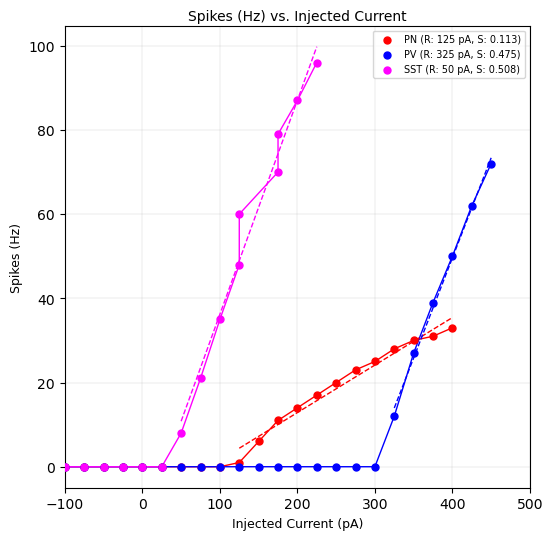

In [ ]:
data_plot = ["PN", "PV", "SST"]
# data_plot = ['SST']
plot_AP_metrics_multi(
    datasets,
    freq_hz       = data_plot,
    xlim=(-100, 500),
    fit=True
)